<a href="https://colab.research.google.com/github/vishcool/AIAgents/blob/main/paddydoctor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


In [3]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

paddy_disease_classification_path = kagglehub.competition_download('paddy-disease-classification')

print('Data source import complete.')


100%|██████████| 1.02G/1.02G [00:12<00:00, 89.9MB/s]

Extracting files...


Data source import complete.


In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

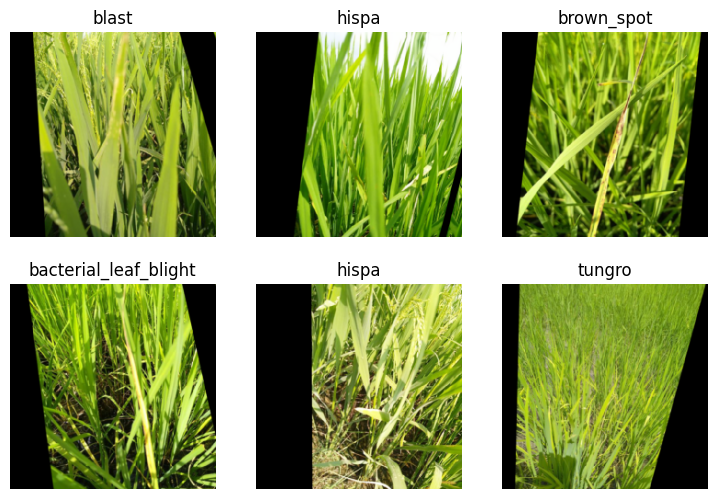

In [5]:
from fastai.vision.all import *

try:
    path = Path(paddy_disease_classification_path)
except NameError:
    import kagglehub
    paddy_disease_classification_path = kagglehub.competition_download('paddy-disease-classification')
    path = Path(paddy_disease_classification_path)

# Set up DataBlock with padding as requested
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=GrandparentSplitter(train_name='train_images', valid_name='train_images'),
    get_y=parent_label,
    item_tfms=Resize(480, method='pad', pad_mode='zeros'),
    batch_tfms=aug_transforms(size=224, min_scale=0.75)
).dataloaders(path/'train_images')

dls.show_batch(max_n=6)

In [6]:
import timm
learn = vision_learner(dls, "resnet26d", metrics=error_rate).to_fp16()
learn.fine_tune(3)

model.safetensors:   0%|          | 0.00/64.2M [00:00<?, ?B/s]

epoch,train_loss,valid_loss,error_rate,time
0,1.618935,0.825695,0.260017,03:10


epoch,train_loss,valid_loss,error_rate,time
0,0.974777,0.517718,0.164024,03:11
1,0.746516,0.350331,0.108581,03:11
2,0.578694,0.310627,0.094744,03:22


### Analyzing Incorrect Predictions
We use `Interpretation` to see where the model is struggling.

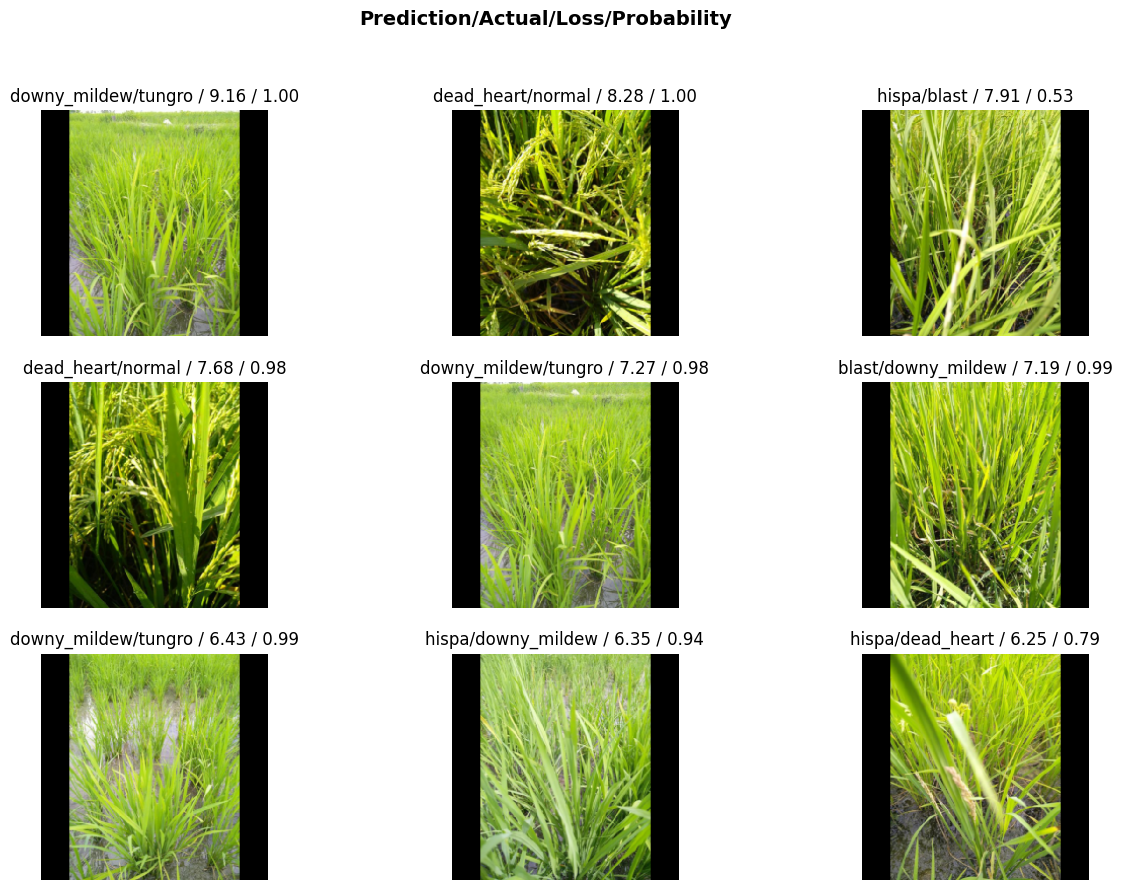

In [7]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_top_losses(9, figsize=(15,10))

### Prediction with Test Time Augmentation (TTA)

In [8]:
# Ensure path is defined for prediction
try:
    _ = path
except NameError:
    path = Path(paddy_disease_classification_path)

test_files = get_image_files(path/'test_images')
tst_dl = dls.test_dl(test_files)

# Applying TTA as requested
preds, _ = learn.tta(dl=tst_dl)

# Create submission
idxs = preds.argmax(dim=1)
vocab = np.array(dls.vocab)
results = pd.Series(vocab[idxs], name='label')
submission = pd.concat([pd.Series([f.name for f in test_files], name='image_id'), results], axis=1)
submission.to_csv('submission.csv', index=False)
display(submission.head())

epoch,train_loss,valid_loss,error_rate,time


<div></div>

,image_id,label
0,200066.jpg,tungro
1,202051.jpg,hispa
2,200725.jpg,normal
3,201183.jpg,blast
4,202392.jpg,bacterial_leaf_streak


In [22]:
import os
import json
from google.colab import userdata

# Best practice: Add your Kaggle 'username' and 'key' to Colab Secrets (the key icon on the left)
# and name them KAG_USERNAME and KAG_KEY.
try:
    KAG_USERNAME = userdata.get('KAG_USERNAME')
    KAG_KEY = userdata.get('KAG_KEY')
except:
    # Manual fallback if you don't want to use Secrets
    KAG_USERNAME = "sreevishnusunilkumar"
    KAG_KEY = "PASTE_YOUR_ACTUAL_API_KEY_HERE"

os.makedirs('/root/.kaggle', exist_ok=True)

with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump({"username": KAG_USERNAME, "key": KAG_KEY}, f)

!chmod 600 /root/.kaggle/kaggle.json
print('Kaggle API key updated. Please ensure you used the Key from your kaggle.json file, not a gating token.')

Kaggle API key updated. Please ensure you used the Key from your kaggle.json file, not a gating token.


In [23]:
# Now try submitting again
!kaggle competitions submit -c paddy-disease-classification -f submission.csv -m "ResNet26d submission with TTA"

401 Client Error: Unauthorized for url: https://api.kaggle.com/v1/competitions.CompetitionApiService/StartSubmissionUpload
